In [ ]:
!pip install pandas

: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from services.data_handling import DataHandling


In [4]:
FILE_PATH = "Book.xlsx"  
SHEET_NAME = "Sheet1"      
METRIC_COL = "Canceled"    
DATE_COL = "Date"

1. Loading Data from Book.xlsx...
2. Initializing DataHandling...
3. Sanitizing data...
4. Imputing data...
   Range: 2024-08-20 to 2025-08-29
5. Running Seasonal Decomposition (Additive)...
   Results saved to: decomposition_results.csv
6. Plotting...


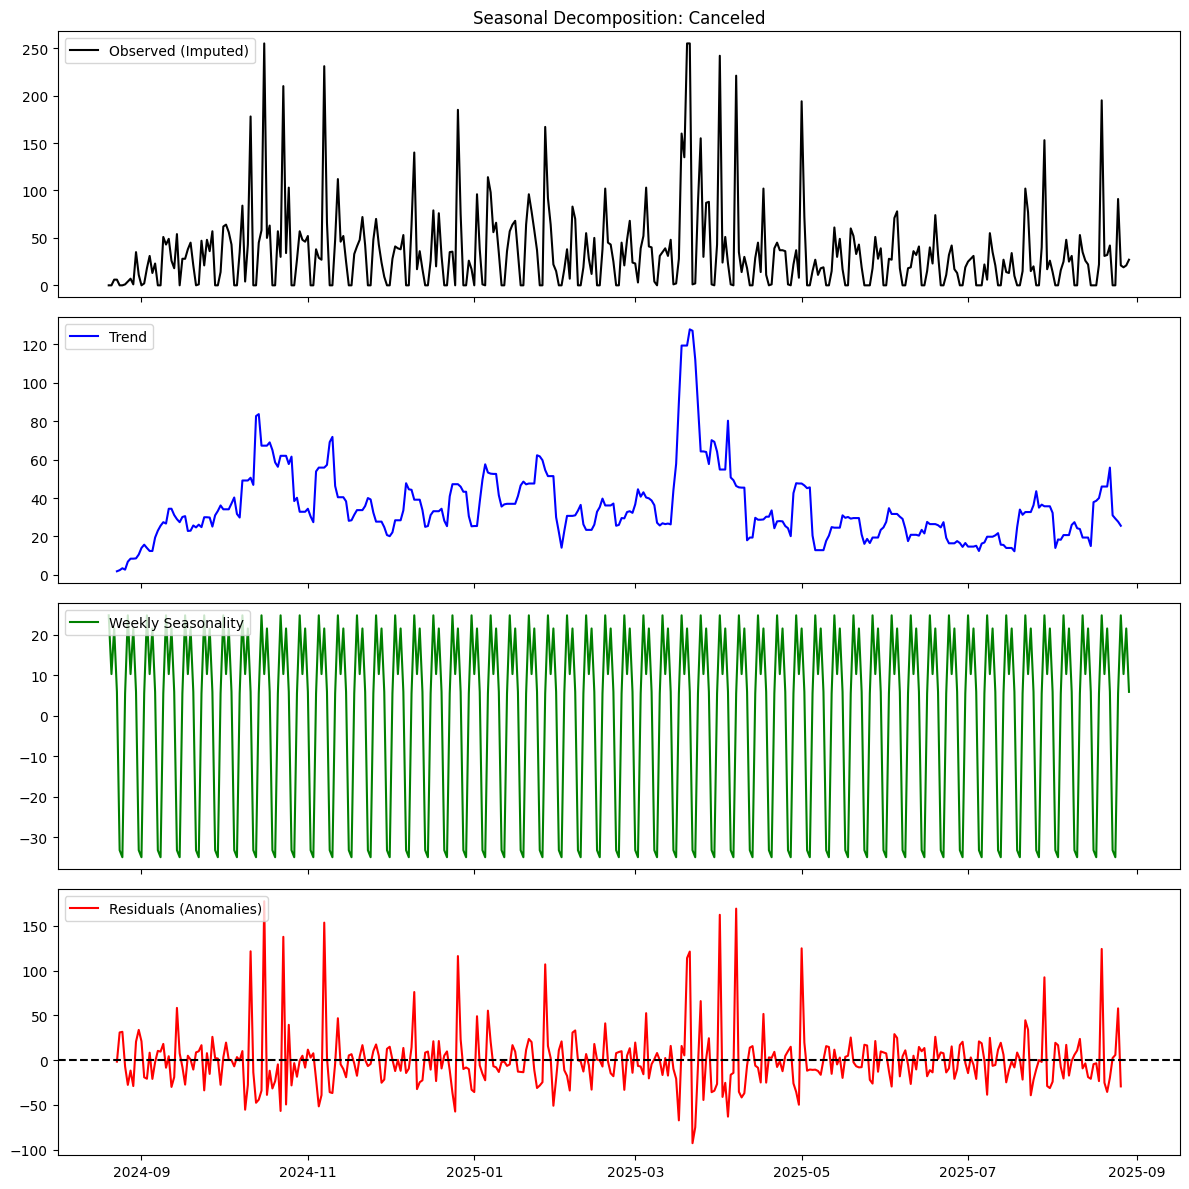

In [5]:
def run_decomposition():
    print(f"1. Loading Data from {FILE_PATH}...")
    try:
        df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
    except Exception as e:
        print(f"   Error: {e}")
        return

    print("2. Initializing DataHandling...")
    dh = DataHandling(min_points=10) 

    print("3. Sanitizing data...")
    clean_series, logs = dh.sanitize(df, DATE_COL, METRIC_COL)
    
    if clean_series is None or clean_series.empty:
        print("   Error: Series is empty after sanitization.")
        return

    print("4. Imputing data...")
    imputed_series = dh.impute_train(clean_series)
    
    imputed_series.index.freq = 'D'

    print(f"   Range: {imputed_series.index.min().date()} to {imputed_series.index.max().date()}")

    print("5. Running Seasonal Decomposition (Additive)...")
    decomposition = seasonal_decompose(imputed_series, model='additive', period=7)

    results_df = pd.DataFrame({
        "Observed": decomposition.observed,
        "Trend": decomposition.trend,
        "Seasonal": decomposition.seasonal,
        "Residual": decomposition.resid
    })

    output_csv = "decomposition_results.csv"
    results_df.to_csv(output_csv)
    print(f"   Results saved to: {output_csv}")

    print("6. Plotting...")
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    axes[0].plot(results_df.index, results_df["Observed"], label='Observed (Imputed)', color='black')
    axes[0].legend(loc='upper left')
    axes[0].set_title(f'Seasonal Decomposition: {METRIC_COL}')

    axes[1].plot(results_df.index, results_df["Trend"], label='Trend', color='blue')
    axes[1].legend(loc='upper left')

    axes[2].plot(results_df.index, results_df["Seasonal"], label='Weekly Seasonality', color='green')
    axes[2].legend(loc='upper left')

    axes[3].plot(results_df.index, results_df["Residual"], label='Residuals (Anomalies)', color='red')
    axes[3].legend(loc='upper left')
    axes[3].axhline(0, color='black', linestyle='--')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_decomposition()